<a href="https://colab.research.google.com/github/TuanSoCode/Power/blob/main/H%E1%BB%8Dc_sink.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vedikagupta0/messy-student-marks-dataset-data-cleaning-practice")

print("Path to dataset files:", path)
import pandas as pd
import numpy as np
!pip install duckdb
import duckdb
import os
print(os.listdir(path))
df=pd.read_csv(path + ("/student_data_part4.csv"))

Using Colab cache for faster access to the 'messy-student-marks-dataset-data-cleaning-practice' dataset.
Path to dataset files: /kaggle/input/messy-student-marks-dataset-data-cleaning-practice
['student_data_part3.csv', 'student_data_part1.csv', 'student_data_part2.csv', 'student_data_part4.csv']


In [ ]:
df.head()

,"""Aarav""",male,Grade 12,50.0,23.0,51 marks,124
0,"""Ananya""",m,02,2,26.0,38 marks,66
1,REYANSH,female,04,50.0,83 marks,17,150
2,'Ishaan',female,Grade 7,52,4 marks,20.0,76
3,ADITI,0,012,0.0,50,45,95
4,ARJUN,Male,9,5 marks,40,74.0,119


In [ ]:
df.tail()

,"""Aarav""",male,Grade 12,50.0,23.0,51 marks,124
994,AARAV,male,1,14 marks,88,96 marks,198
995,"""Reyansh""",female,3,13,59,47 marks,119
996,'Ishaan',M,Grade 5,37,5,48.0,90
997,ZARA,male,012,64 marks,20.0,7.0,91
998,DIYA,Male,010,65,58 marks,28.0,151


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   "Aarav"   999 non-null    object
 1   male      999 non-null    object
 2   Grade 12  999 non-null    object
 3   50.0      999 non-null    object
 4   23.0      999 non-null    object
 5   51 marks  999 non-null    object
 6   124       999 non-null    int64 
dtypes: int64(1), object(6)
memory usage: 54.8+ KB


In [ ]:
df.describe()

,124
count,999.000000
mean,147.960961
std,49.036973
min,8.000000
25%,114.000000
50%,149.000000
75%,181.000000
max,300.000000


In [ ]:
df.isnull().sum()

,0
"""Aarav""",0
male,0
Grade 12,0
50.0,0
23.0,0
51 marks,0
124,0


In [ ]:
df.nunique()

,0
"""Aarav""",80
male,12
Grade 12,36
50.0,291
23.0,296
51 marks,298
124,212


In [ ]:
df.rename(columns={'"Aarav"': "Students","male": "Gender","Grade 12":"Grade","50.0":"score_component_1","23.0":"score_component_2","51 marks":"score_component_3","124":"total_score"},inplace=True)

In [ ]:
mask=["Students","Gender"]
df[mask]=df[mask].apply(lambda x: x.str.title())
df["Students"]=df["Students"].str.strip('"\'')

In [ ]:
df["Grade"]=df["Grade"].str.extract(r'(\d+)').astype(int)

In [ ]:
df["Gender"]=df["Gender"].str.strip()
df["Gender"]=df["Gender"].replace(["M","F"],np.nan)
df["Gender"]=df["Gender"].replace(["0","1"],np.nan)

df=df.dropna(subset=["Gender"])
df["score_component_1"]=df["score_component_1"].str.extract(r'(\d+)').astype(int)
df["score_component_2"]=df["score_component_2"].str.extract(r'(\d+)').astype(int)
df["score_component_3"]=df["score_component_3"].str.extract(r'(\d+)').astype(int)

In [ ]:
df["Gender"].unique()

array(['Female', 'Male'], dtype=object)

In [ ]:
df.head()

,Students,Gender,Grade,score_component_1,score_component_2,score_component_3,total_score
1,Reyansh,Female,4,50,83,17,150
2,Ishaan,Female,7,52,4,20,76
4,Arjun,Male,9,5,40,74,119
7,Rohan,Male,9,27,87,43,157
12,Ishaan,Female,3,31,57,47,135


In [ ]:
df.nunique()

,0
Students,20
Gender,2
Grade,12
score_component_1,99
score_component_2,97
score_component_3,95
total_score,149


In [ ]:
df.groupby("Grade")["total_score"].mean()

,total_score
Grade,
1,134.971429
2,146.125000
3,149.043478
4,157.230769
5,151.458333
6,133.407407
7,159.666667
8,141.166667
9,149.592593


In [ ]:
df.tail(50)

,Students,Gender,Grade,score_component_1,score_component_2,score_component_3,total_score
833,Navya,Female,9,44,31,70,145
834,Krishna,Female,10,40,39,87,166
843,Myra,Female,10,92,67,6,165
844,Shaurya,Male,12,92,49,78,219
848,Isha,Male,2,71,50,95,216
849,Krishna,Female,3,2,55,13,70
854,Navya,Male,5,62,29,28,119
858,Aditi,Female,6,96,0,77,173
867,Ishaan,Male,6,75,3,30,108
872,Ishaan,Female,3,7,20,19,46


In [ ]:
df.groupby("Grade").size()

,0
Grade,
1,35
2,32
3,23
4,26
5,24
6,27
7,33
8,30
9,27


In [ ]:
df.describe()

,Grade,score_component_1,score_component_2,score_component_3,total_score
count,327.000000,327.000000,327.000000,327.000000,327.000000
mean,6.220183,47.247706,48.819572,50.039755,146.107034
std,3.441958,29.068405,28.509301,28.960545,48.737662
min,1.000000,0.000000,0.000000,1.000000,8.000000
25%,3.000000,23.000000,24.000000,22.000000,116.000000
50%,6.000000,47.000000,50.000000,50.000000,147.000000
75%,9.000000,71.000000,72.000000,76.000000,179.000000
max,12.000000,100.000000,100.000000,100.000000,267.000000


In [ ]:
duckdb.query(""" SELECT AVG("total_score") as AVG,
MIN("total_score") as Min ,
MAX("total_score") as Max from df """)

┌────────────────────┬───────┬───────┐
│        AVG         │  Min  │  Max  │
│       double       │ int64 │ int64 │
├────────────────────┼───────┼───────┤
│ 146.10703363914374 │     8 │   267 │
└────────────────────┴───────┴───────┘

In [ ]:
duckdb.query("""SELECT CASE
WHEN "total_score" < 100 THEN 'Thấp'
WHEN "total_score" < 200
THEN 'TB'
ELSE 'cao'END AS "Nhóm",COUNT(*) AS Students FROM df GROUP BY "Nhóm" """)

┌─────────┬──────────┐
│  Nhóm   │ Students │
│ varchar │  int64   │
├─────────┼──────────┤
│ cao     │       44 │
│ TB      │      224 │
│ Thấp    │       59 │
└─────────┴──────────┘

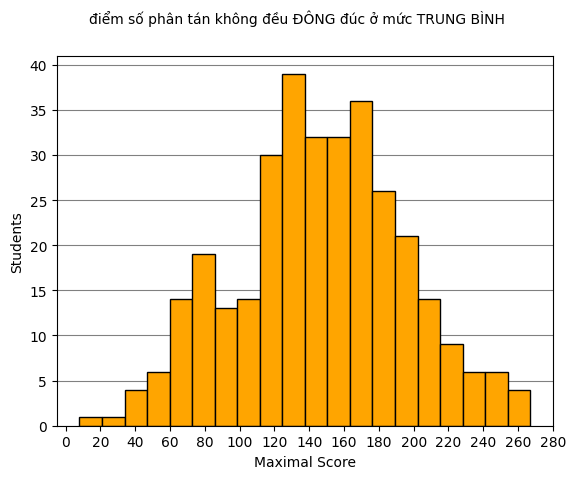

In [ ]:
import matplotlib.pyplot as plt
plt.grid(axis="y",zorder= 1,color="gray")
plt.hist(df["total_score"],bins=20, edgecolor="black",color="orange",zorder=2)
plt.ylabel("Students")
plt.xlabel("Maximal Score")
plt.xticks(range(0,300,20))
plt.figtext(0.5,0.95,"điểm số phân tán không đều ĐÔNG đúc ở mức TRUNG BÌNH",ha="center",color="black")
plt.savefig("hoc_sink.png" , dpi=200, bbox_inches="tight")